# Assignment 1 — Unsupervised Learning Methods
## Task 2: Preprocessing & Feature Engineering
**Dataset:** Heart Disease UCI — `processed.cleveland.data`  
**Goal:** Encode categorical features, standardise the data, apply PCA for visualisation,
and perform supervised feature selection to define the final feature set for clustering.

This task follows a structured pipeline:
1. Encode nominal features correctly
2. Standardise all features to a common scale
3. **Step A** — Apply PCA for visualisation and variance analysis
4. **Step B** — Perform supervised feature selection using a hybrid voting strategy

---
### 2.1 Imports & Setup

In [1]:
# Standard data-science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools from scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split

# Reproducibility
np.random.seed(42)

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
### 2.2 Data Loading & Cleaning

We reload the Heart Disease dataset directly from the UCI repository, following the same
procedure as Task 1. Missing
values in `ca` and `thal` are removed via listwise deletion (6 rows, <2% of the dataset),
and the target is binarised: 0 = no disease, 1 = disease present (original values 1–4).

> The target `y` is kept **completely separate** from `X` throughout this task.
> It will only be used briefly in Step B for supervised feature selection, then set aside
> until Task 6 evaluation.

In [2]:
%pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch the Heart Disease dataset (id=45 is its unique identifier on UCI)
heart_disease = fetch_ucirepo(id=45)

# Extract features and target
# .squeeze() converts the single-column DataFrame target into a 1D Series
X = heart_disease.data.features
y = heart_disease.data.targets.squeeze()

# Drop rows with any missing values (affects ca and thal only, as found in Task 1)
valid_idx = X.dropna().index
X = X.loc[valid_idx].reset_index(drop=True)
y = y.loc[valid_idx].reset_index(drop=True)

# Binarise target: 0 = no disease, 1 = disease present (original values 1–4)
y = (y > 0).astype(int)

# Sanity check
print(f'X shape: {X.shape}')     # Expected: (297, 13)
print(f'\nFeature columns:\n{list(X.columns)}')
print(f'y shape: {y.shape}')     # Expected: (297,)
print(f'\nTarget counts:\n{y.value_counts().sort_index()}')

X shape: (297, 13)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
y shape: (297,)

Target counts:
num
0    160
1    137
Name: count, dtype: int64


---
### 2.3 Encoding Categorical Features

Before scaling or modelling, we decide how to represent each feature numerically.

We first inspect each feature's unique values to inform this decision.

In [4]:
# Overview of every feature: type, unique values, and range
for col in X.columns:
    uniques = sorted(X[col].dropna().unique())
    n_unique = len(uniques)
    dtype = X[col].dtype

    # If few unique values, show them all — otherwise show min/max
    if n_unique <= 8:
        values_str = str(uniques)
    else:
        values_str = f'[{X[col].min():.1f} ... {X[col].max():.1f}]  ({n_unique} unique values)'

    print(f'{col:<10} | dtype: {str(dtype):<8} | unique: {n_unique:<3} | values: {values_str}')

age        | dtype: int64    | unique: 41  | values: [29.0 ... 77.0]  (41 unique values)
sex        | dtype: int64    | unique: 2   | values: [np.int64(0), np.int64(1)]
cp         | dtype: int64    | unique: 4   | values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
trestbps   | dtype: int64    | unique: 50  | values: [94.0 ... 200.0]  (50 unique values)
chol       | dtype: int64    | unique: 152 | values: [126.0 ... 564.0]  (152 unique values)
fbs        | dtype: int64    | unique: 2   | values: [np.int64(0), np.int64(1)]
restecg    | dtype: int64    | unique: 3   | values: [np.int64(0), np.int64(1), np.int64(2)]
thalach    | dtype: int64    | unique: 91  | values: [71.0 ... 202.0]  (91 unique values)
exang      | dtype: int64    | unique: 2   | values: [np.int64(0), np.int64(1)]
oldpeak    | dtype: float64  | unique: 40  | values: [0.0 ... 6.2]  (40 unique values)
slope      | dtype: int64    | unique: 3   | values: [np.int64(1), np.int64(2), np.int64(3)]
ca         | dtype: 

Based on the feature inspection above, we classify each feature into one of three types and apply the appropriate treatment:

**Numerical features** are kept as-is: they carry true quantitative meaning and their scale will be handled by StandardScaler in section 2.4.

**Ordinal features** are also kept as raw integers. Although they are categorical in nature, their values encode a genuine ordering with clinically meaningful progression.Treating them as numerical allows the algorithm to respect that ordering without artificially expanding the feature space. One-hot encoding would destroy this ordinal information.

**Nominal features** are one-hot encoded: their numeric labels are arbitrary and
imply no ordering or distance. Feeding them raw would impose false mathematical
relationships (e.g. implying `thal=7` is "more than twice" `thal=3`).

| Feature | Type | Treatment | Reason |
|---|---|---|---|
| `age`, `trestbps`, `chol`, `thalach`, `oldpeak` | Continuous | Keep as-is + scale | True quantities on a natural scale |
| `sex`, `fbs`, `exang` | Binary (0/1) | Keep as-is, no scaling | Only two states, already on natural 0/1 scale |
| `slope` | Ordinal (1→2→3) | Keep as-is + scale | Upsloping→flat→downsloping: genuine medical progression |
| `ca` | Ordinal (0→1→2→3) | Keep as-is + scale | Number of vessels — real count, order is meaningful |
| `cp` | Nominal (4 chest pain types) | One-hot encode | No consistent clinical gradient between types |
| `restecg` | Nominal (3 ECG categories) | One-hot encode | Three distinct result types, not steps on a scale |
| `thal` | Nominal (3 defect types) | One-hot encode | Arbitrary labels: 3, 6, 7 imply no ordering |

**One-hot encoding** creates one binary column per category so the algorithm treats each category as a distinct dimension with no implied ordering or distance.

We deliberately keep all dummy columns. In clustering, there is no matrix inversion that breaks with redundant columns. More importantly, with all dummies retained, dropping any single category column during feature selection (Step B) still leaves each patient's category **fully identifiable** from the remaining dummies, avoiding the ambiguity that arises when a reference category is only implicitly encoded as 'all zeros'. This is especially relevant for `thal` and `restecg` where rare category columns may be dropped.

In [5]:
# One-hot encode the three nominal features
nominal_features = ['cp', 'restecg', 'thal']

X_encoded = pd.get_dummies(X, columns=nominal_features, drop_first=False)

# Ensure dummy columns are integers (0/1) rather than booleans
dummy_cols = [c for c in X_encoded.columns if c not in X.columns]
X_encoded[dummy_cols] = X_encoded[dummy_cols].astype(int)

print(f'Shape before encoding: {X.shape}')
print(f'Shape after encoding:  {X_encoded.shape}')
print(f'\nNew columns created:')
print(dummy_cols)
print(f'\nAll columns now:')
X_encoded.head(3)

Shape before encoding: (297, 13)
Shape after encoding:  (297, 20)

New columns created:
['cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_1', 'restecg_2', 'thal_3.0', 'thal_6.0', 'thal_7.0']

All columns now:


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,cp_4,restecg_0,restecg_1,restecg_2,thal_3.0,thal_6.0,thal_7.0
0,63,1,145,233,1,150,0,2.3,3,0.0,1,0,0,0,0,0,1,0,1,0
1,67,1,160,286,0,108,1,1.5,2,3.0,0,0,0,1,0,0,1,1,0,0
2,67,1,120,229,0,129,1,2.6,2,2.0,0,0,0,1,0,0,1,0,0,1


---
### 2.4 Feature Scaling

Feature scaling is applied **selectively** based on variable type, following
the standard practice of applying StandardScaler to numerical variables only.

**Continuous and ordinal variables** (`age`, `trestbps`, `chol`, `thalach`,
`oldpeak`, `slope`, `ca`) are standardised using StandardScaler — they represent
quantitative or ordered measurements across varying ranges that need to be brought
to a comparable scale for distance-based algorithms. Without scaling, features with
larger magnitudes (e.g. `chol` spanning ~100–560) would dominate Euclidean distance
calculations regardless of their clinical relevance.

**Binary and one-hot encoded variables** (`sex`, `fbs`, `exang`, `cp_*`,
`restecg_*`, `thal_*`) are left unscaled. StandardScaler is designed for continuous
variables — applying it to categorical encodings has no statistical justification
and would implicitly re-weight rare categories by amplifying their variance
contribution purely due to low frequency.

**Why StandardScaler over MinMaxScaler or RobustScaler?**

| Scaler | Behaviour | Limitation |
|---|---|---|
| **MinMaxScaler** | Maps to [0, 1] | One extreme value pulls $x_{max}$ up, compressing all other values near 0 — loses discriminative information |
| **StandardScaler** | Maps to mean=0, std=1 | Outliers become large z-scores but do not compress the rest of the distribution |
| **RobustScaler** | Uses median and IQR | Most outlier-resistant but less standard in this type of pipeline |

Task 1 identified right-skewed distributions with outliers in `oldpeak`
(most values 0–2, max 6.2) and `chol` (most values 150–350, max 564).
MinMaxScaler would compress the majority of patients into a narrow range
near 0 for these features, losing most discriminative information.
StandardScaler handles this better — outliers become large z-scores but
the bulk of the distribution retains its spread and discriminative power.
RobustScaler would be even more outlier-resistant but is less commonly
used in this type of preprocessing pipeline and would be an interesting
alternative to explore in future work.

> This scaler is fitted on the **full dataset** here for PCA visualisation only.
> In Step B, a separate scaler is fitted **only on the training set** to avoid
> data leakage into the feature selection process.

In [6]:
# ── Define feature groups for scaling ─────────────────────────────────────────
# dummy_cols contains all one-hot encoded columns from the encoding step
# We also exclude binary features (sex, fbs, exang) from scaling
# since they are already on a natural 0/1 scale

binary_original = ['sex', 'fbs', 'exang']
continuous_ordinal = [c for c in X_encoded.columns
                      if c not in dummy_cols and c not in binary_original]
no_scale = dummy_cols + binary_original

print(f'Continuous/ordinal (will be scaled) : {continuous_ordinal}')
print(f'Binary/dummy (kept as 0/1)          : {no_scale}')

Continuous/ordinal (will be scaled) : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope', 'ca']
Binary/dummy (kept as 0/1)          : ['cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_1', 'restecg_2', 'thal_3.0', 'thal_6.0', 'thal_7.0', 'sex', 'fbs', 'exang']


In [7]:
# ── Scale only continuous and ordinal features ────────────────────────────────
# Fit StandardScaler on the full dataset (for PCA visualisation only)
# In Step B we will refit on training data only to avoid leakage

scaler = StandardScaler()

# Scale continuous/ordinal only
X_cont_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded[continuous_ordinal]),
    columns=continuous_ordinal
)

# Keep binary/dummy as-is
X_bin = X_encoded[no_scale].reset_index(drop=True)

# Combine into final scaled DataFrame — preserving original column order
X_scaled_df = pd.concat([X_cont_scaled, X_bin], axis=1)
X_scaled_df = X_scaled_df[X_encoded.columns]  # restore original column order

# Verify
print(f'Shape: {X_scaled_df.shape}')
print(f'\nContinuous/ordinal — mean (should be ≈ 0):')
print(X_scaled_df[continuous_ordinal].mean().round(4))
print(f'\nContinuous/ordinal — std (should be ≈ 1):')
print(X_scaled_df[continuous_ordinal].std().round(4))
print(f'\nBinary/dummy — still 0/1:')
print(X_scaled_df[no_scale].describe().loc[['min','max']].round(2))

# For PCA we need a numpy array
X_scaled = X_scaled_df.values

Shape: (297, 20)

Continuous/ordinal — mean (should be ≈ 0):
age        -0.0
trestbps    0.0
chol       -0.0
thalach     0.0
oldpeak     0.0
slope      -0.0
ca         -0.0
dtype: float64

Continuous/ordinal — std (should be ≈ 1):
age         1.0017
trestbps    1.0017
chol        1.0017
thalach     1.0017
oldpeak     1.0017
slope       1.0017
ca          1.0017
dtype: float64

Binary/dummy — still 0/1:
     cp_1  cp_2  cp_3  cp_4  restecg_0  restecg_1  restecg_2  thal_3.0  \
min   0.0   0.0   0.0   0.0        0.0        0.0        0.0       0.0   
max   1.0   1.0   1.0   1.0        1.0        1.0        1.0       1.0   

     thal_6.0  thal_7.0  sex  fbs  exang  
min       0.0       0.0  0.0  0.0    0.0  
max       1.0       1.0  1.0  1.0    1.0  


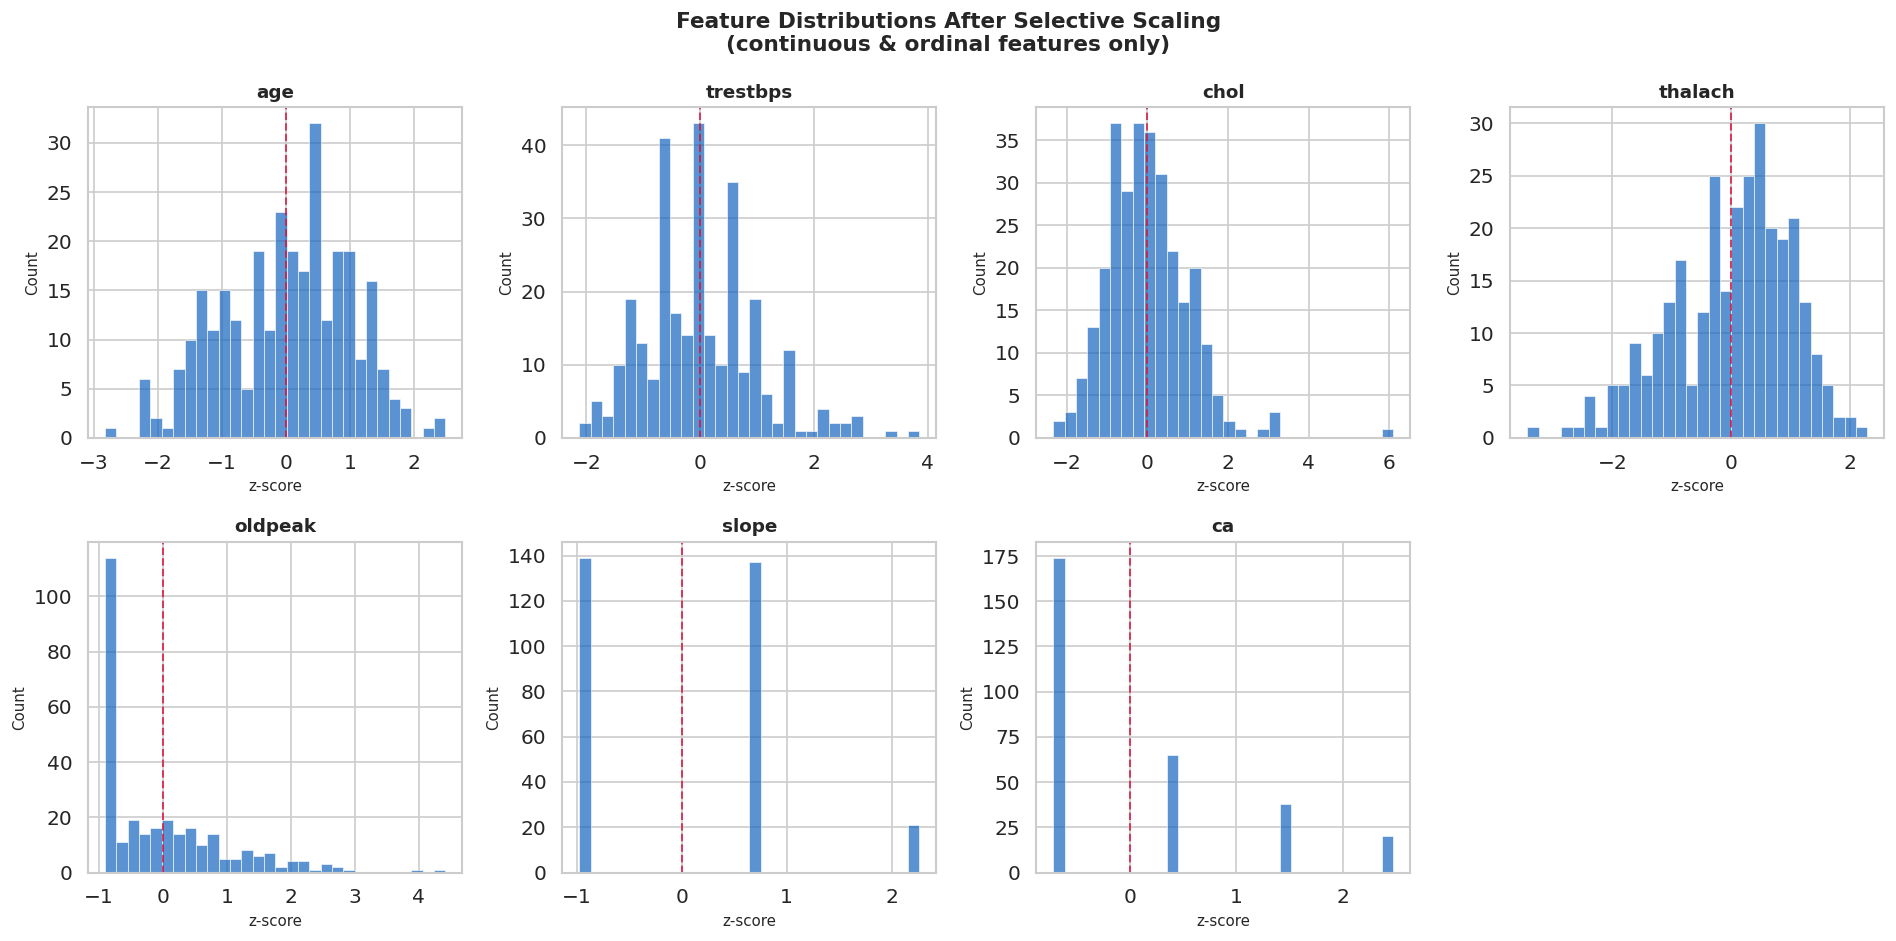

Skewness after scaling:
 age       : -0.219
 trestbps  : 0.697
 chol      : 1.112
 thalach   : -0.534
 oldpeak   : 1.241
 slope     : 0.508
 ca        : 1.174


In [8]:
# ── Visualise distributions after selective scaling ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(continuous_ordinal):
 axes[i].hist(X_scaled_df[feat], bins=30, color='#1565C0',
 alpha=0.7, edgecolor='white', linewidth=0.5)
 axes[i].set_title(feat, fontsize=11, fontweight='bold')
 axes[i].set_xlabel('z-score', fontsize=9)
 axes[i].set_ylabel('Count', fontsize=9)
 axes[i].axvline(x=0, color='crimson', linestyle='--',
 linewidth=1.2, alpha=0.8, label='mean=0')

# Hide unused subplot
 axes[-1].set_visible(False)

 plt.suptitle('Feature Distributions After Selective Scaling\n(continuous & ordinal features only)',
 fontsize=13, fontweight='bold')
 plt.tight_layout()
plt.show()

# Quick check — print skewness for each feature
from scipy.stats import skew
print('Skewness after scaling:')
for feat in continuous_ordinal:
 s = skew(X_scaled_df[feat])
 print(f' {feat:<10}: {s:.3f}')

---
### 2.5 Step A — Principal Component Analysis (PCA)

PCA finds new axes — called **principal components** — that capture the directions of
maximum variance in the data. Each PC is a linear combination of all original features,
and they are ordered so that PC1 always explains the most variance, PC2 the second most,
and so on.

We apply PCA here for two purposes:
1. **Variance analysis** — how many dimensions are needed to capture most of the data's structure?
2. **Visualisation** — project 20D data onto 2D (PC1 & PC2) to visually inspect structure
   and later overlay cluster assignments from Tasks 3–5

> PCA is used here **for visualisation only**.

#### 2.5.1 — Fit Full PCA & Explained Variance

In [9]:
# Fit PCA retaining all components to see the full variance spectrum
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_scaled)

# Extract explained variance per component and cumulatively
evr = pca_full.explained_variance_ratio_      # How much variance each PC explains
cumulative_evr = np.cumsum(evr)               # Running total

print(f'Total components: {len(evr)}')
print(f'\nVariance per component:')
for i, (v, cv) in enumerate(zip(evr, cumulative_evr), start=1):
    print(f'  PC{i:>2d}: {v*100:.2f}%   Cumulative: {cv*100:.2f}%')

Total components: 20

Variance per component:
  PC 1: 27.64%   Cumulative: 27.64%
  PC 2: 13.99%   Cumulative: 41.63%
  PC 3: 10.62%   Cumulative: 52.24%
  PC 4: 9.24%   Cumulative: 61.49%
  PC 5: 8.17%   Cumulative: 69.66%
  PC 6: 5.93%   Cumulative: 75.59%
  PC 7: 5.04%   Cumulative: 80.63%
  PC 8: 4.17%   Cumulative: 84.80%
  PC 9: 3.96%   Cumulative: 88.76%
  PC10: 3.00%   Cumulative: 91.76%
  PC11: 2.08%   Cumulative: 93.84%
  PC12: 1.65%   Cumulative: 95.49%
  PC13: 1.42%   Cumulative: 96.92%
  PC14: 1.18%   Cumulative: 98.10%
  PC15: 0.90%   Cumulative: 99.00%
  PC16: 0.80%   Cumulative: 99.80%
  PC17: 0.20%   Cumulative: 100.00%
  PC18: 0.00%   Cumulative: 100.00%
  PC19: 0.00%   Cumulative: 100.00%
  PC20: 0.00%   Cumulative: 100.00%


#### 2.5.2 — Explained Variance Ratio Plots

We plot two complementary views: the variance explained by each individual component,
and the cumulative variance as we include more components (both with a defined 85% threshold).

In [10]:
# Determine the number of components needed to explain at least 85% variance
n_85 = np.argmax(cumulative_evr >= 0.85) + 1  # +1 because argmax returns 0-indexed position
print(f'Components needed for ≥85% variance: {n_85}')
print(f'Cumulative variance at PC{n_85}: {cumulative_evr[n_85-1]*100:.2f}%')

Components needed for ≥85% variance: 9
Cumulative variance at PC9: 88.76%


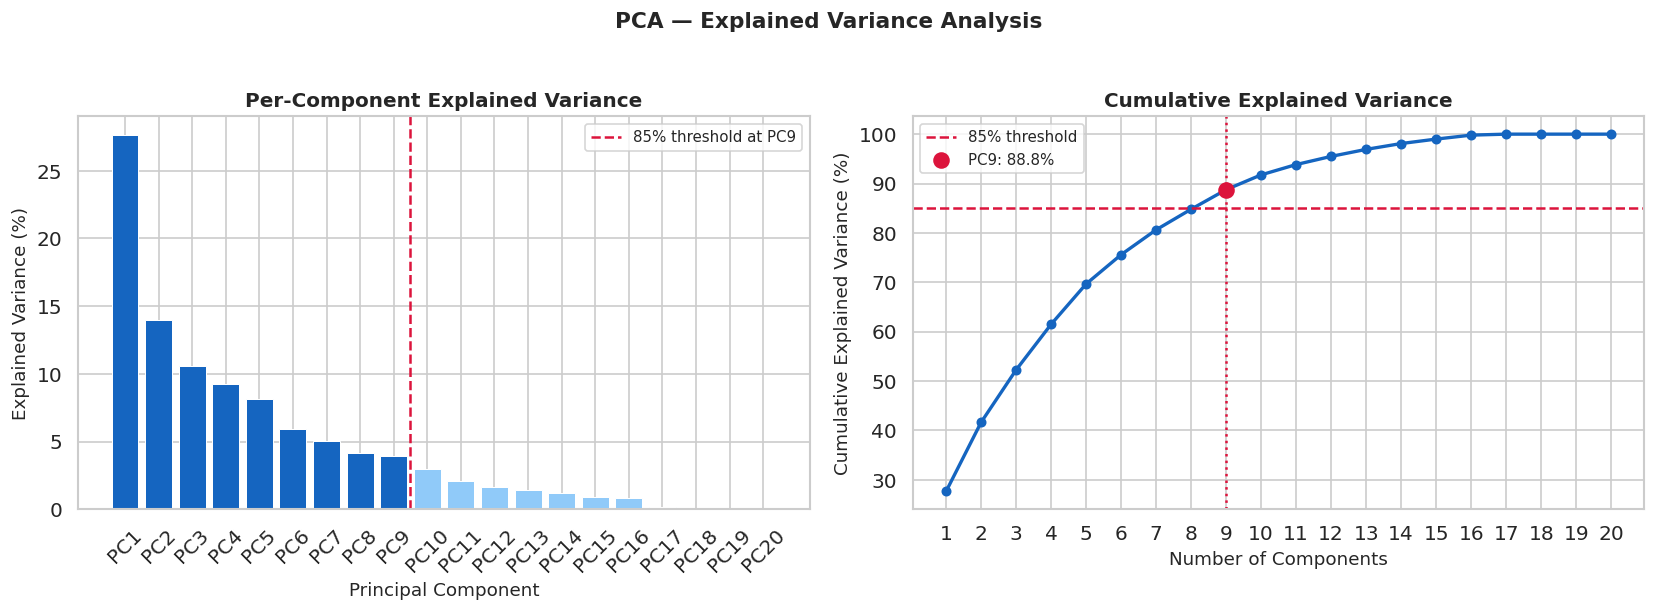

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

component_labels = [f'PC{i}' for i in range(1, len(evr) + 1)]

# ── Left: per-component bar chart ──────────────────────────────────────────
ax1 = axes[0]
# Blue for components we keep, light blue for the rest
colors = ['#1565C0' if i < n_85 else '#90CAF9' for i in range(len(evr))]

ax1.bar(component_labels, evr * 100, color=colors, edgecolor='white', linewidth=0.6)
ax1.axvline(x=n_85 - 0.5, color='crimson', linestyle='--', linewidth=1.5,
            label=f'85% threshold at PC{n_85}')
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance (%)', fontsize=11)
ax1.set_title('Per-Component Explained Variance', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9)

# ── Right: cumulative explained variance ────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, len(evr) + 1), cumulative_evr * 100,
         marker='o', markersize=5, color='#1565C0', linewidth=2)
ax2.axhline(y=85, color='crimson', linestyle='--', linewidth=1.5, label='85% threshold')
ax2.axvline(x=n_85, color='crimson', linestyle=':', linewidth=1.5)
ax2.scatter([n_85], [cumulative_evr[n_85-1] * 100],
            color='crimson', zorder=5, s=80,
            label=f'PC{n_85}: {cumulative_evr[n_85-1]*100:.1f}%')
ax2.set_xlabel('Number of Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
ax2.set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, len(evr) + 1))
ax2.legend(fontsize=9)

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Left plot — Per-Component Explained Variance:**
PC1 explains 27.64% of the total variance, capturing the dominant direction in
the data — the continuous cardiac stress axis driven by `oldpeak`, `thalach`,
`slope` and `age`. After PC2 (14.0%) the decline is gradual with no clear elbow,
confirming the data has no dominant low-dimensional structure — information is
distributed across many partially independent clinical dimensions.

PC18, PC19 and PC20 explain exactly 0%. This is expected: within each one-hot
group (`cp`, `restecg`, `thal`), exactly one dummy is always 1 — making the
last dummy of each group perfectly predictable from the others and contributing
no independent variance.

**Right plot — Cumulative Explained Variance:**
**9 components are needed to reach the 85% threshold** (88.76% at PC9), reflecting
the complexity of this dataset — heart disease involves multiple partially independent
clinical axes each contributing a modest share of variance.

**PCA is used here for visualisation only** — the 2D projection onto PC1 and PC2
(41.6% of variance combined) provides a visual map of the data structure used
throughout Tasks 3–5 to display cluster assignments.

#### 2.5.3 — 2D Visualisation in PCA Space

We project all 297 patients onto PC1 and PC2 to create a 2D map of the data.
We show two panels: the unlabelled view (as seen by the clustering algorithm) and
the ground truth overlay (for reference only — not used in clustering).

In [12]:
# Project all 297 patients onto the first two principal components
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

print(f'PC1: {var_pc1:.2f}%')
print(f'PC2: {var_pc2:.2f}%')
print(f'Combined: {var_pc1 + var_pc2:.2f}%')

PC1: 27.64%
PC2: 13.99%
Combined: 41.63%


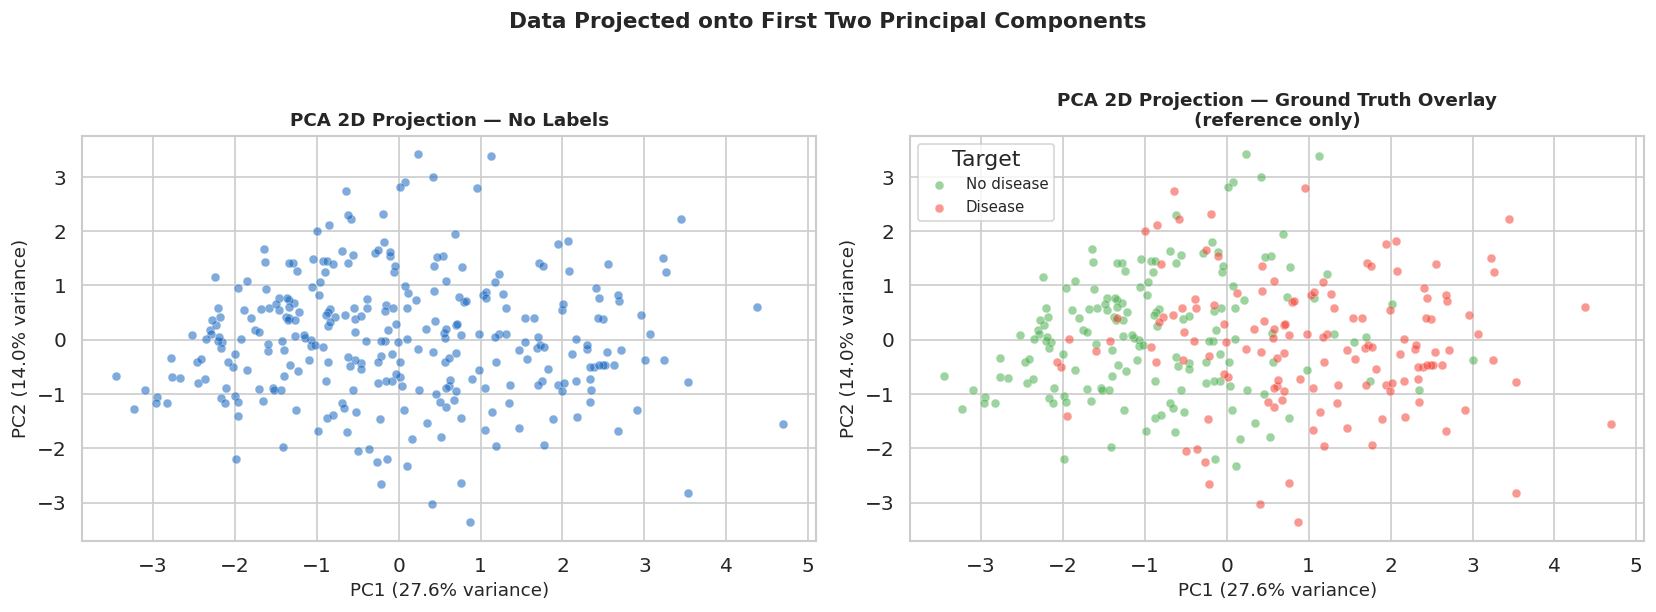

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: no labels (as seen by clustering algorithm) ──────────────────────
ax1 = axes[0]
ax1.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
            alpha=0.55, s=28, color='#1565C0',
            edgecolors='white', linewidths=0.3)
ax1.set_xlabel(f'PC1 ({var_pc1:.1f}% variance)', fontsize=11)
ax1.set_ylabel(f'PC2 ({var_pc2:.1f}% variance)', fontsize=11)
ax1.set_title('PCA 2D Projection — No Labels', fontsize=11, fontweight='bold')

# ── Right: coloured by ground truth (reference only) ───────────────────────
ax2 = axes[1]
palette = {0: '#4CAF50', 1: '#F44336'}
labels  = {0: 'No disease', 1: 'Disease'}

for label in [0, 1]:
    mask = y == label
    ax2.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=labels[label],
                alpha=0.55, s=28,
                color=palette[label],
                edgecolors='white', linewidths=0.3)

ax2.set_xlabel(f'PC1 ({var_pc1:.1f}% variance)', fontsize=11)
ax2.set_ylabel(f'PC2 ({var_pc2:.1f}% variance)', fontsize=11)
ax2.set_title('PCA 2D Projection — Ground Truth Overlay\n(reference only)',
              fontsize=11, fontweight='bold')
ax2.legend(title='Target', fontsize=9)

plt.suptitle('Data Projected onto First Two Principal Components',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Left plot — No Labels:**
Without the ground truth, visually separating two clusters is almost impossible.
The point cloud appears as one continuous overlapping mass with no clear boundary —
confirming that mathematical clustering techniques are needed to detect structure
the human eye cannot see in this 2D projection.

**Right plot — Ground Truth Overlay:**
When the target is revealed, a partial separation emerges along the **horizontal
axis (PC1)** — disease-free patients (green) tend to cluster on the left while
disease patients (red) concentrate on the right, consistent with PC1 capturing
the cardiac stress axis (`oldpeak`, `thalach`, `slope`). However, the separation
is less pronounced than it would be if all features were scaled uniformly. This
is a direct consequence of our selective scaling choice.

There is considerable **overlap in the centre**, reflecting the known clinical
heterogeneity of heart disease — not all patients present with the same profile.

**Key limitation:** This 2D projection captures only 41.6% of total variance.
The remaining ~58% lives in dimensions not shown here — additional separation
likely exists there, which the clustering algorithms in Tasks 3–5 will exploit
by operating on the full selected feature space.

#### 2.5.4 — PCA Component Loadings

The loadings heatmap shows **how much each original feature contributes to each PC**.
Features with large absolute loadings on PC1 drive the main variance direction.
Inspecting the loadings helps us verify our clinical hypotheses and later compare
the PCA structure with the results of supervised feature selection in Step B.

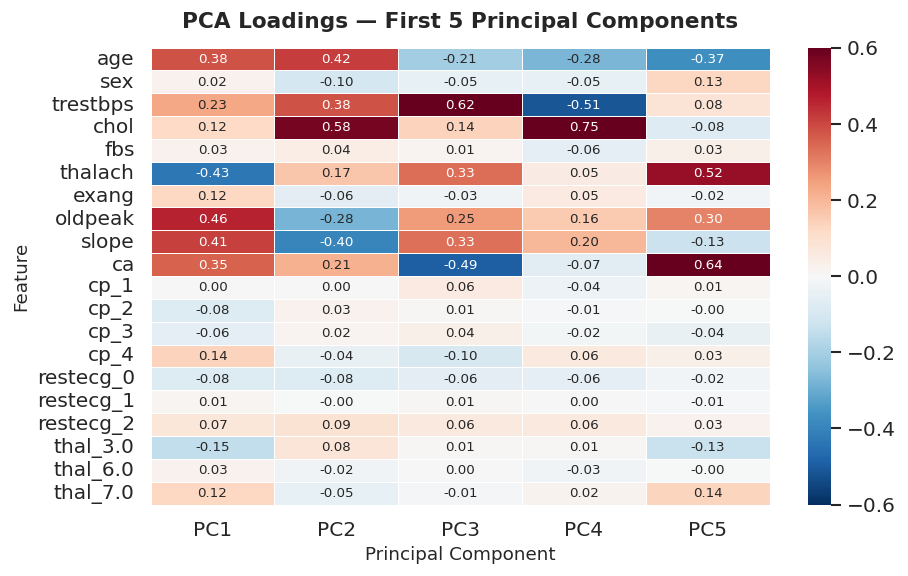


=== Loadings Table — sorted by |PC1| ===
             PC1    PC2    PC3    PC4    PC5
oldpeak    0.459 -0.280  0.254  0.159  0.296
thalach   -0.433  0.166  0.333  0.047  0.523
slope      0.412 -0.397  0.331  0.201 -0.129
age        0.380  0.415 -0.210 -0.276 -0.371
ca         0.353  0.213 -0.493 -0.067  0.642
trestbps   0.230  0.381  0.619 -0.512  0.084
thal_3.0  -0.149  0.075  0.009  0.008 -0.131
cp_4       0.139 -0.045 -0.099  0.057  0.033
thal_7.0   0.122 -0.051 -0.010  0.019  0.135
exang      0.122 -0.064 -0.028  0.052 -0.021
chol       0.117  0.575  0.138  0.754 -0.078
cp_2      -0.083  0.027  0.007 -0.006 -0.000
restecg_0 -0.082 -0.082 -0.065 -0.060 -0.021
restecg_2  0.070  0.085  0.059  0.057  0.027
cp_3      -0.060  0.017  0.037 -0.015 -0.043
thal_6.0   0.027 -0.024  0.001 -0.027 -0.004
fbs        0.026  0.043  0.015 -0.058  0.035
sex        0.024 -0.104 -0.051 -0.050  0.130
restecg_1  0.011 -0.003  0.005  0.003 -0.006
cp_1       0.004  0.001  0.055 -0.036  0.010


In [14]:
# Show loadings for the first 5 PCs
n_show = 5
loadings = pd.DataFrame(
    pca_full.components_[:n_show].T,
    index=X_encoded.columns,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-0.6, vmax=0.6,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('PCA Loadings — First 5 Principal Components',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

# Print loadings as a ranked table for easier reading
# Sort by absolute PC1 loading to identify the most influential features
print('\n=== Loadings Table — sorted by |PC1| ===')
loadings_display = loadings.copy()
loadings_display['|PC1|'] = loadings['PC1'].abs()
loadings_display = loadings_display.sort_values('|PC1|', ascending=False)
loadings_display = loadings_display.drop(columns='|PC1|')
print(loadings_display.round(3).to_string())

**PC1 — Continuous Cardiac Stress Axis:**
PC1 is dominated by continuous and ordinal features: `oldpeak` (+0.46),
`thalach` (−0.43), `slope` (+0.41), `age` (+0.38), `ca` (+0.35) and
`trestbps` (+0.23). This is the **exercise-induced ischaemia and cardiovascular
burden axis** — patients with high ST depression, low max heart rate, downsloping
ST segment, older age and more diseased vessels score high on PC1 and are more
likely to have heart disease. The 2D scatter confirms this — disease patients
concentrate on the positive side of PC1.

Binary and dummy features have near-zero PC1 loadings (< 0.15). This is a direct
consequence of selective scaling — by not inflating their variance to unit std,
categorical features contribute minimally to PC1. Their discriminative power is
not lost however — it is captured by the supervised filter methods in Step B,
and these features are fully present in the final clustering matrix.

**PC2 — Metabolic Risk Axis:**
PC2 is driven by `chol` (+0.58), `age` (+0.42), `trestbps` (+0.38) and
`slope` (−0.40). This axis contrasts patients who are metabolically burdened
(high cholesterol, older, high blood pressure) against those showing acute
exercise stress response — two partially independent clinical dimensions.

**PC3–PC5:**
`trestbps` dominates PC3 (+0.62), while `ca` and `chol` dominate PC4 and PC5
respectively. These components capture more specific clinical interactions with
progressively smaller contributions to total variance.

**Key takeaway for Step B:** Features with near-zero loadings across all five
components — `fbs`, `restecg_1`, `cp_1` — carry limited structural information
and are strong candidates for exclusion by the supervised filter methods.

---
### 2.6 Step B — Supervised Feature Selection

PCA showed that **9 components are needed to explain 85% of variance** — retaining
all 20 encoded features for clustering would introduce noise and worsen the performance
of distance-based algorithms (curse of dimensionality). Feature selection reduces the
space to the most informative subset while keeping features clinically interpretable,
unlike PCA which creates abstract components with no direct clinical meaning.

**Why filter methods?**
We deliberately choose filter methods over wrapper or embedded methods. Wrapper methods
select features optimised for a *specific* learning algorithm — but since we plan to
run three different clustering algorithms in Tasks 3–5, a model-agnostic approach is
more appropriate. Filter methods evaluate features based on their statistical properties
alone, independently of any downstream model.

**Hybrid voting strategy:**
We run three complementary filter methods and retain a feature only if selected by
**at least 2 out of 3 methods** (majority vote). This approach removes subjectivity from the final decision and
ensures only features with broad cross-method support are retained.

| Method | Category | What it captures |
|---|---|---|
| **ANOVA F-test** | Univariate filter | Tests whether each feature's mean differs significantly between disease and no-disease patients |
| **ReliefF** | Multivariate filter | Weights features by how well they distinguish nearest-neighbour patients across classes |
| **mRMR** | Multivariate filter | Selects features with maximum relevance to target AND minimum redundancy with already-selected features |

> The target label `y` is used **only in this step** — exclusively on the training
> set (237 patients). After the voting decision, `y` is set aside until Task 6.

#### 2.6.1 — Train / Test Split

We split the data **before** any feature selection to prevent data leakage. If we
selected features using all 297 patients and then evaluated the same patients, the
selection would be influenced by patients it shouldn't have seen. Stratification
(`stratify=y`) ensures the disease/no-disease ratio is preserved in both sets.

In [15]:
# Split before feature selection to avoid data leakage
# stratify=y ensures class proportions are preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set shape : {X_train.shape}')
print(f'Test set shape     : {X_test.shape}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts().sort_index())
print(f'\nClass distribution in test set:')
print(y_test.value_counts().sort_index())

Training set shape : (237, 20)
Test set shape     : (60, 20)

Class distribution in training set:
num
0    128
1    109
Name: count, dtype: int64

Class distribution in test set:
num
0    32
1    28
Name: count, dtype: int64


In [16]:
# ── Scale only continuous/ordinal — fitted on training set only ───────────────
scaler_train = StandardScaler()

# Fit and transform training set (continuous/ordinal only)
X_train_cont_scaled = pd.DataFrame(
    scaler_train.fit_transform(X_train[continuous_ordinal]),
    columns=continuous_ordinal
)

# Transform test set using training statistics (no fitting)
X_test_cont_scaled = pd.DataFrame(
    scaler_train.transform(X_test[continuous_ordinal]),
    columns=continuous_ordinal
)

# Keep binary/dummy as-is for both sets
X_train_bin = X_train[no_scale].reset_index(drop=True)
X_test_bin  = X_test[no_scale].reset_index(drop=True)

# Combine and restore column order
X_train_enc = pd.concat([X_train_cont_scaled, X_train_bin], axis=1)[X_encoded.columns]
X_test_enc  = pd.concat([X_test_cont_scaled,  X_test_bin],  axis=1)[X_encoded.columns]

# Initialise voting list
features_selected_lists = []

print(f'X_train_enc shape: {X_train_enc.shape}')
print(f'X_test_enc shape : {X_test_enc.shape}')

X_train_enc shape: (237, 20)
X_test_enc shape : (60, 20)


#### 2.6.2 — Method 1: ANOVA F-test (kbest)

The ANOVA F-test asks: **'Is the mean of this feature significantly different between
disease and no-disease patients?'** A high F-statistic means the feature clearly
separates the two groups; a high p-value means any difference could be due to chance.

We use p < 0.05 as the significance threshold — a feature must show a statistically
significant mean difference between classes to be selected by this method.

kbest (ANOVA) — features selected (p < 0.05): 15
['age', 'sex', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_2', 'thal_3.0', 'thal_7.0']


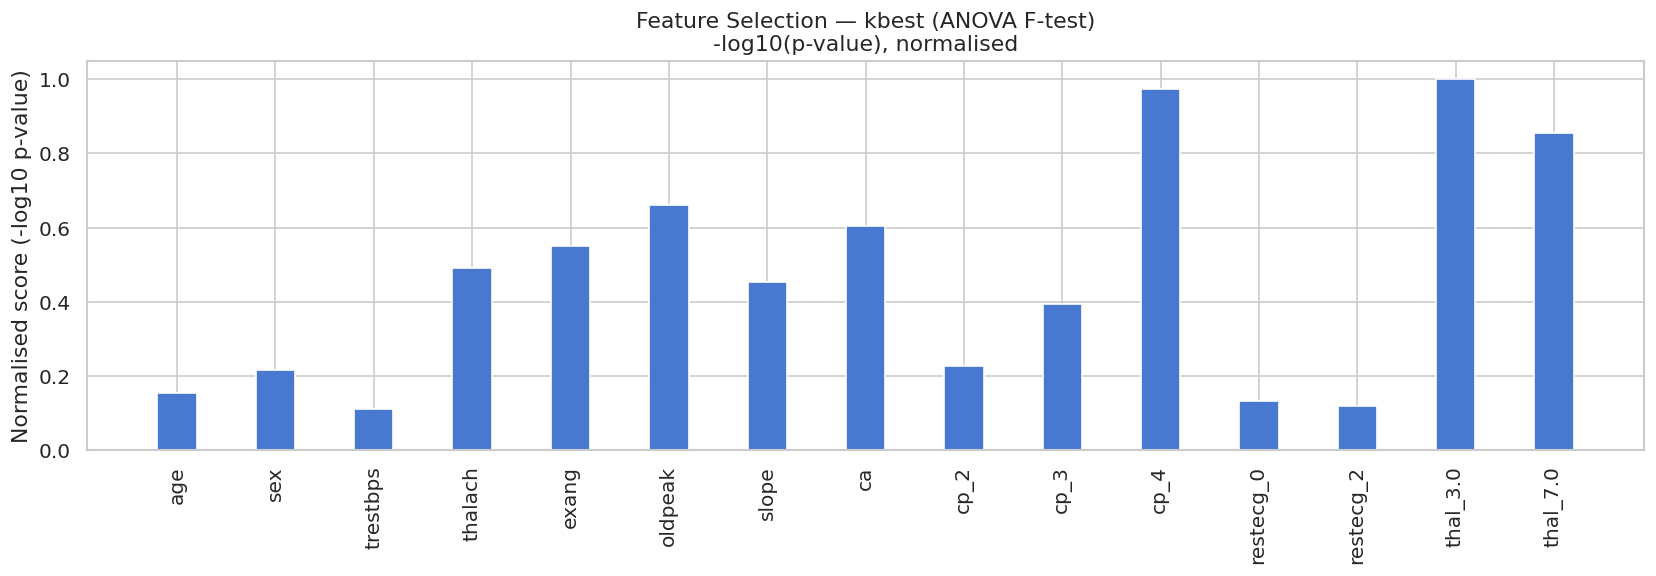

In [17]:
# ── Method 1: kbest (ANOVA F-test) ───────────────────────────────────────────
# use p-value threshold instead of arbitrary k
# We use p < 0.05 (standard significance threshold)

fs1 = SelectKBest(score_func=f_classif, k='all')
fs1.fit(X_train_enc, y_train.reset_index(drop=True))

# Get negative log of p-values (higher = more significant)
kbest_scores = -np.log10(fs1.pvalues_)

# Select features below p-value threshold
cols_kbest = np.where(fs1.pvalues_ < 0.05)[0]
kbest_features = list(X_train_enc.columns[cols_kbest])

print(f'kbest (ANOVA) — features selected (p < 0.05): {len(kbest_features)}')
print(kbest_features)

# Add to the voting list
features_selected_lists.append(kbest_features)

# Plot
plt.figure(figsize=(14, 5))
plt.bar(range(len(cols_kbest)),
        kbest_scores[cols_kbest] / kbest_scores[cols_kbest].max(),
        width=0.4)
plt.title('Feature Selection — kbest (ANOVA F-test)\n-log10(p-value), normalised')
plt.xticks(range(len(cols_kbest)),
           X_train_enc.columns[cols_kbest], rotation=90)
plt.ylabel('Normalised score (-log10 p-value)')
plt.tight_layout()
plt.show()

#### 2.6.3 — Method 2: ReliefF

ReliefF is a **multivariate** filter that takes a different approach to ANOVA. Rather
than looking at each feature independently, it assesses each feature by asking:
*'Does this feature help distinguish patients that are close to each other but belong
to different classes?'*

For each patient, ReliefF finds its nearest same-class neighbour (nearHit) and nearest
different-class neighbour (nearMiss), then updates each feature's weight based on whether
the feature value is similar within the same class and different across classes.

Features with **positive scores** are informative; features with **negative or zero
scores** actually hurt classification. We retain only positive-score features.

  Preparing metadata (setup.py) ... done
  Created wheel for skrebate: filename=skrebate-0.62-py3-none-any.whl size=29253 sha256=3bb6a43ea05b5d6926bdfbe938b836ffeb63b61252c1ec853082e2ad194d6a12
  Stored in directory: /root/.cache/pip/wheels/03/4c/36/bc6b70d88998635e0ec0e617d15cd97483f5008d6bb77c1c7a
Successfully built skrebate
ReliefF — features with positive score: 19
['thal_3.0', 'cp_4', 'thal_7.0', 'exang', 'slope', 'ca', 'oldpeak', 'cp_3', 'thalach', 'sex', 'age', 'restecg_0', 'cp_2', 'restecg_2', 'cp_1', 'thal_6.0', 'chol', 'trestbps', 'restecg_1']


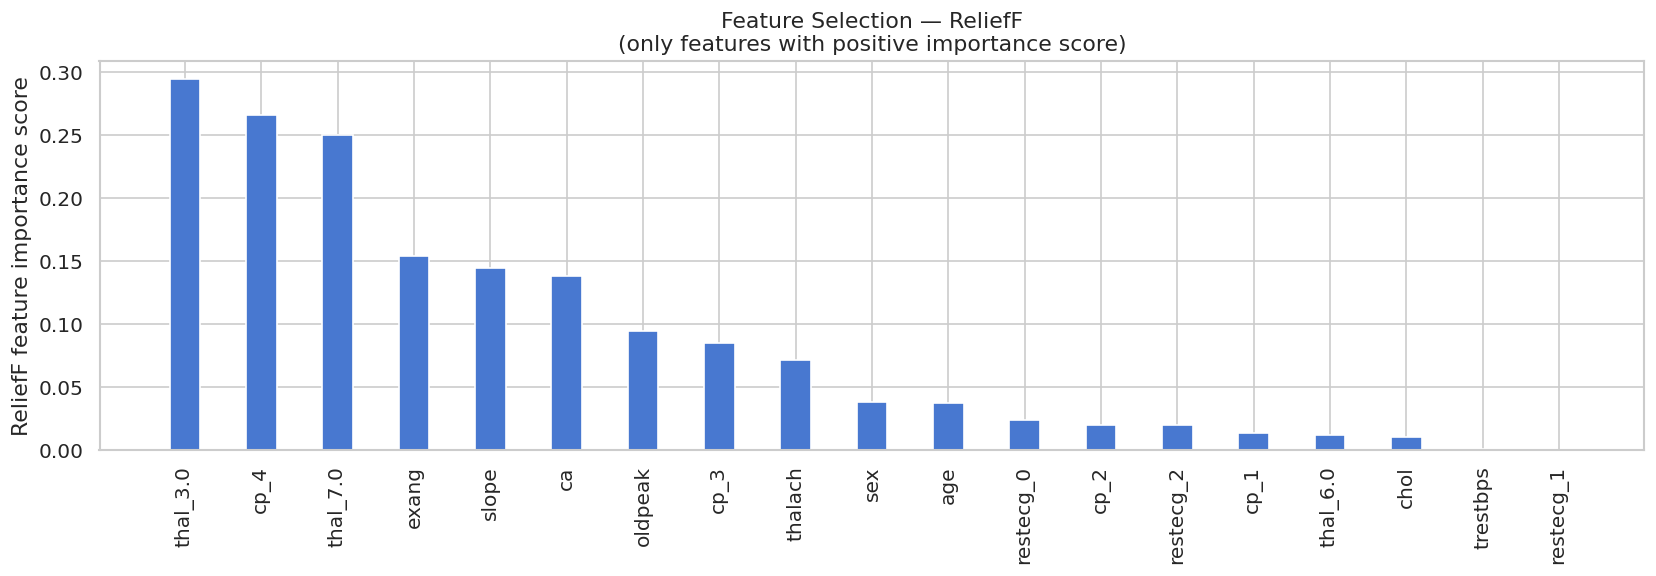

In [18]:
# ── Method 2: ReliefF ─────────────────────────────────────────────────────────
%pip install skrebate
from skrebate import ReliefF

# n_features_to_select = all features to get full ranking
# n_neighbors = 100
reliefFS = ReliefF(n_features_to_select=X_train_enc.shape[1],
                   n_neighbors=100,
                   n_jobs=-1)

# Fit on training data only
reliefFS.fit(X_train_enc.values.astype(float),
             y_train.reset_index(drop=True).values)

# Get scores and ranked feature indices
relief_scores = reliefFS.feature_importances_
relief_ranked = reliefFS.top_features_

# Select features with positive scores (negative = hurts classification)
cols_relief = [i for i in relief_ranked if relief_scores[i] > 0]
relief_features = list(X_train_enc.columns[cols_relief])

print(f'ReliefF — features with positive score: {len(relief_features)}')
print(relief_features)

# Add to voting list
features_selected_lists.append(relief_features)

# Plot
plt.figure(figsize=(14, 5))
plt.bar(range(len(cols_relief)),
        relief_scores[cols_relief],
        width=0.4)
plt.title('Feature Selection — ReliefF\n(only features with positive importance score)')
plt.xticks(range(len(cols_relief)),
           X_train_enc.columns[cols_relief], rotation=90)
plt.ylabel('ReliefF feature importance score')
plt.tight_layout()
plt.show()

#### 2.6.4 — Method 3: mRMR (Minimum Redundancy Maximum Relevance)

mRMR is a **multivariate** filter that addresses a limitation of both ANOVA and ReliefF:
those methods rank features *independently*, so they can select a group of features that
are all highly discriminative but highly correlated with each other — essentially saying
the same thing multiple times.

mRMR iteratively selects features that are **maximally relevant** to the target AND
**minimally redundant** with already-selected features. This is particularly important
for our dataset, where Task 1 identified strong correlations among exercise stress
markers (`oldpeak`, `exang`, `thalach`, `slope`).

We run mRMR for all 20 features (K=20) to get the complete ranking, then use the
top 10 as the selected subset

In [19]:
%pip install mrmr-selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


100%|██████████| 17/17 [00:00<00:00, 23.78it/s]


mRMR — top 10 features:
  1. thal_3.0
  2. restecg_0
  3. cp_4
  4. ca
  5. oldpeak
  6. thal_7.0
  7. exang
  8. thalach
  9. cp_3
  10. slope


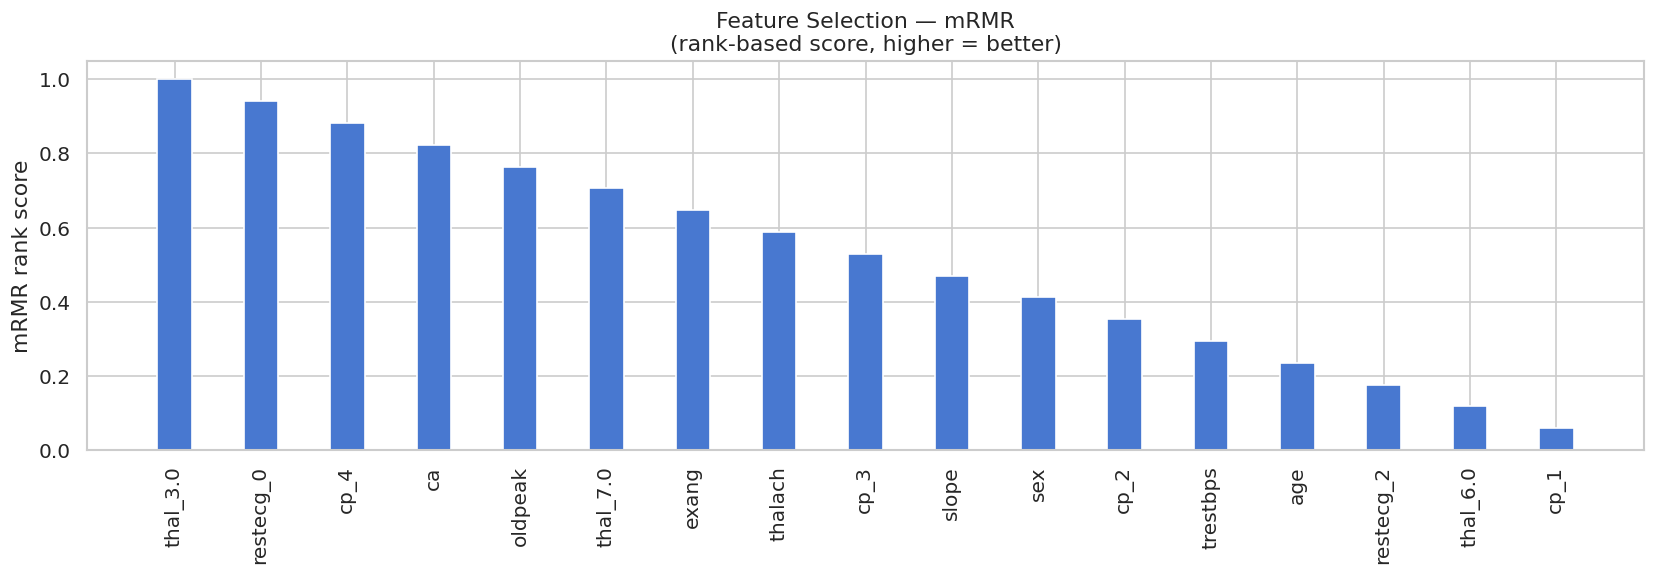

In [20]:
# ── Method 3: mRMR ────────────────────────────────────────────────────────────
from mrmr import mrmr_classif

# Run mRMR for all 17 features to get complete ranking
mrmr_selected = mrmr_classif(
    X = X_train_enc,
    y = y_train.reset_index(drop=True),
    K = 17
)

# Select features with positive relevance
# Following the same logic as kbest — we take the top features
# For mRMR we take the top features until relevance drops significantly
# Here we take top 10 as a reasonable cutoff
mrmr_features = list(mrmr_selected[:10])

print(f'mRMR — top 10 features:')
for i, feat in enumerate(mrmr_features, start=1):
    print(f'  {i}. {feat}')

# Add to voting list
features_selected_lists.append(mrmr_features)

# Plot
mrmr_scores = {feat: (17-i)/17 for i, feat in enumerate(mrmr_selected)}
plt.figure(figsize=(14, 5))
plt.bar(range(len(mrmr_selected)),
        [(17-i)/17 for i in range(len(mrmr_selected))],
        width=0.4)
plt.title('Feature Selection — mRMR\n(rank-based score, higher = better)')
plt.xticks(range(len(mrmr_selected)), mrmr_selected, rotation=90)
plt.ylabel('mRMR rank score')
plt.tight_layout()
plt.show()

#### 2.6.5 — Hybrid Voting

Each method has now contributed its selected feature list to `features_selected_lists`.
We now apply the voting rule: **a feature is retained if and only if it was selected
by at least 2 out of the 3 methods** (majority vote). This ensures the final feature
set has broad cross-method support and avoids over-relying on any single method's
assumptions or blind spots.

In [21]:
# ── Hybrid Voting ─────────────────────────────────────────────────────────────
# Following teacher's structure exactly
# A feature is retained if selected by at least 2 out of 3 methods

from collections import Counter

# Flatten all selected features into one list
flat_list = [feat for method_list in features_selected_lists for feat in method_list]

# Count how many methods selected each feature
counter = Counter(flat_list)

# Keep features with at least 2 votes
min_votes = 2
final_features = [feat for feat, votes in counter.items() if votes >= min_votes]

# Sort for readability
final_features = sorted(final_features)

print('=== Voting Results ===')
print(f'{"Feature":<15} {"Votes":>6}  {"Selected"}')
print('-' * 35)
for feat in sorted(counter.keys()):
    votes = counter[feat]
    selected = '✅' if votes >= min_votes else '❌'
    print(f'{feat:<15} {votes:>6}  {selected}')

print(f'\nFinal feature set ({len(final_features)} features):')
print(final_features)

=== Voting Results ===
Feature          Votes  Selected
-----------------------------------
age                  2  ✅
ca                   3  ✅
chol                 1  ❌
cp_1                 1  ❌
cp_2                 2  ✅
cp_3                 3  ✅
cp_4                 3  ✅
exang                3  ✅
oldpeak              3  ✅
restecg_0            3  ✅
restecg_1            1  ❌
restecg_2            2  ✅
sex                  2  ✅
slope                3  ✅
thal_3.0             3  ✅
thal_6.0             1  ❌
thal_7.0             3  ✅
thalach              3  ✅
trestbps             2  ✅

Final feature set (15 features):
['age', 'ca', 'cp_2', 'cp_3', 'cp_4', 'exang', 'oldpeak', 'restecg_0', 'restecg_2', 'sex', 'slope', 'thal_3.0', 'thal_7.0', 'thalach', 'trestbps']


**Voting results — features dropped (1/3 votes):**

- **`chol`** (1/3) — only ReliefF selected it. Not statistically significant in
  ANOVA (p=0.31). Despite being a classic cardiovascular risk marker, serum
  cholesterol shows limited discriminative power in this sample, likely due to
  insufficient statistical power at n=297.

- **`cp_1`** (1/3) — only ReliefF selected it. Typical angina (cp=1) affects
  only 23/297 patients (8%) — too rare to show reliable statistical signal in
  ANOVA or mRMR. Note that the other chest pain types (`cp_2`, `cp_3`, `cp_4`)
  are all retained, so chest pain information is well represented.

- **`thal_6.0`** (1/3) — only ReliefF. Fixed defect category contains only
  18/297 patients (6%) — statistically underpowered. With `thal_3.0` and
  `thal_7.0` both retained, patients with `thal_6.0=0` AND `thal_7.0=0` AND
  `thal_3.0=0` are unambiguously identified as fixed defect — no information
  is lost.

- **`restecg_1`** (1/3) — only ReliefF. LVH category contains only 4/297
  patients (<2%) — effectively absent from the dataset and statistically
  meaningless.

- **`fbs`** (0/3) — rejected by all three methods. Near-zero F-statistic
  (0.04, p=0.83), zero ReliefF score, absent from mRMR top 10. Fasting blood
  sugar >120 mg/dl affects only 15% of patients with near-identical rates across
  disease and no-disease groups (Task 1).

#### 2.6.6 — Build Final Clustering Matrix

We now apply the final feature set to the full dataset (all 297 patients) using the
scaler fitted on the training set only — this ensures no leakage from test patients
into the scaling parameters.

In [22]:
# ── Build final clustering matrix ─────────────────────────────────────────────
# Step 1: scale continuous/ordinal using scaler fitted on training set only
X_full_cont_scaled = pd.DataFrame(
    scaler_train.transform(X_encoded[continuous_ordinal]),
    columns=continuous_ordinal
)

# Step 2: keep binary/dummy as-is
X_full_bin = X_encoded[no_scale].reset_index(drop=True)

# Step 3: combine and restore column order
X_full_scaled_df = pd.concat([X_full_cont_scaled, X_full_bin], axis=1)[X_encoded.columns]

# Step 4: select only the final voted features
X_cluster_df = X_full_scaled_df[final_features].copy()

print(f'Final clustering matrix shape: {X_cluster_df.shape}')
print(f'  → {X_cluster_df.shape[0]} patients × {X_cluster_df.shape[1]} features')
print(f'\nFeatures retained: {final_features}')

Final clustering matrix shape: (297, 15)
  → 297 patients × 15 features

Features retained: ['age', 'ca', 'cp_2', 'cp_3', 'cp_4', 'exang', 'oldpeak', 'restecg_0', 'restecg_2', 'sex', 'slope', 'thal_3.0', 'thal_7.0', 'thalach', 'trestbps']


#### 2.6.7 — Comparing Feature Selection with PCA Loadings

We compare the voting scores against **both PC1 and PC2 loadings**
— looking at only PC1 would be misleading since the data has two main clinical axes.

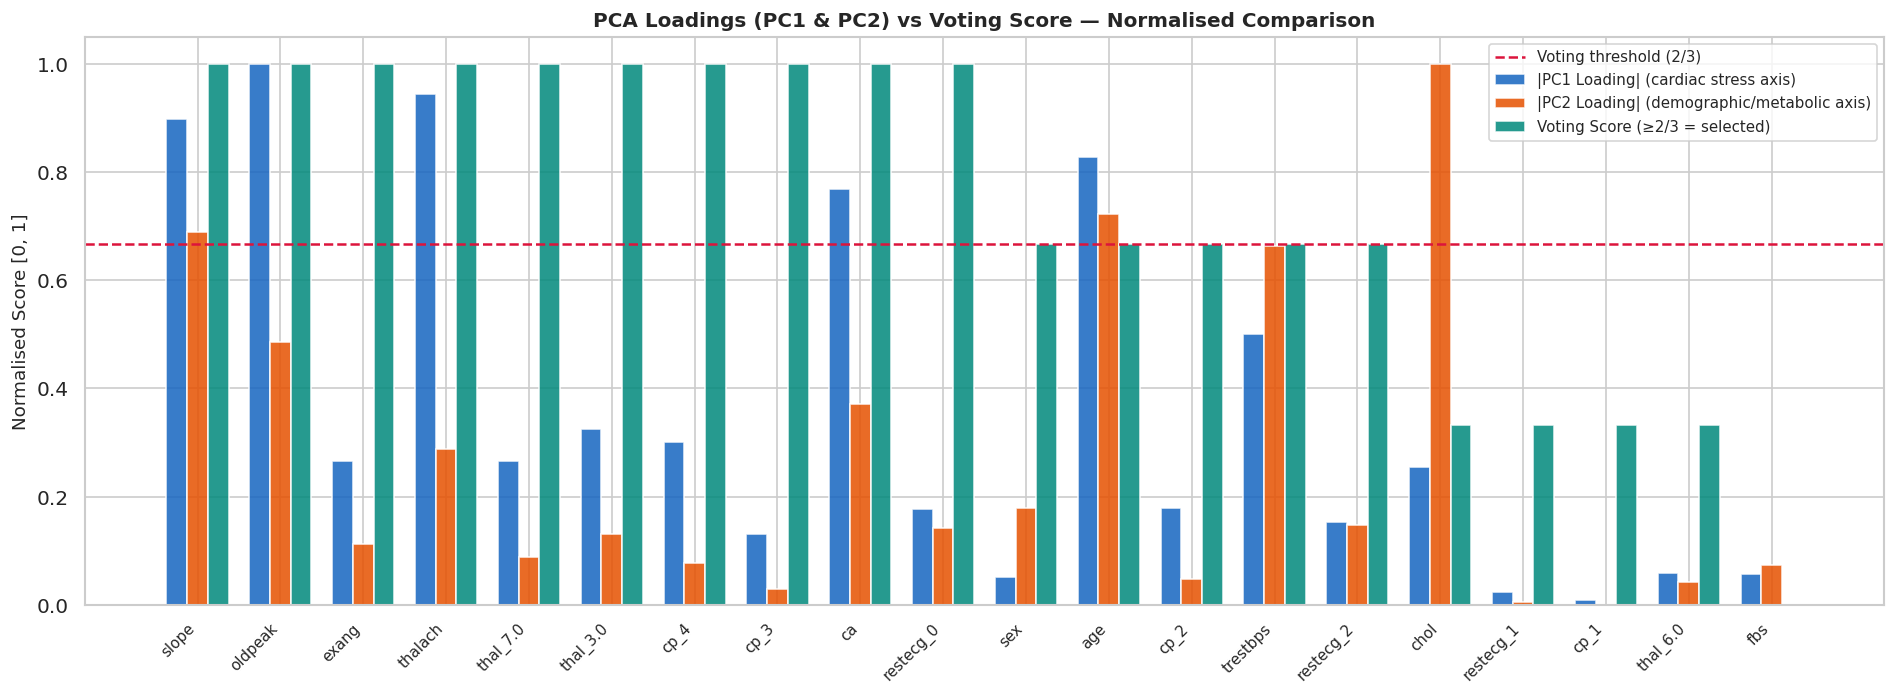

Features with |PC1| or |PC2| loading > 0.2 : ['age', 'ca', 'chol', 'cp_4', 'exang', 'oldpeak', 'slope', 'thal_3.0', 'thal_7.0', 'thalach', 'trestbps']
Of those, retained by voting               : ['age', 'ca', 'cp_4', 'exang', 'oldpeak', 'slope', 'thal_3.0', 'thal_7.0', 'thalach', 'trestbps']
Of those, NOT retained by voting           : ['chol']


In [23]:
# ── Compare voting with PC1 AND PC2 loadings ──────────────────────────────────
pc1_loadings = pd.Series(
    np.abs(pca_full.components_[0]),
    index=X_encoded.columns
)
pc2_loadings = pd.Series(
    np.abs(pca_full.components_[1]),
    index=X_encoded.columns
)

# Normalise all to [0,1]
pc1_norm  = pc1_loadings / pc1_loadings.max()
pc2_norm  = pc2_loadings / pc2_loadings.max()
vote_norm = pd.Series({feat: counter.get(feat, 0)
                       for feat in X_encoded.columns}) / 3

# Sort by vote score
comparison_df = pd.DataFrame({
    '|PC1 Loading|': pc1_norm,
    '|PC2 Loading|': pc2_norm,
    'Vote Score'   : vote_norm
}).sort_values('Vote Score', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
x     = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['|PC1 Loading|'],
       width, label='|PC1 Loading| (cardiac stress axis)',
       color='#1565C0', alpha=0.85, edgecolor='white')
ax.bar(x, comparison_df['|PC2 Loading|'],
       width, label='|PC2 Loading| (demographic/metabolic axis)',
       color='#E65100', alpha=0.85, edgecolor='white')
ax.bar(x + width, comparison_df['Vote Score'],
       width, label='Voting Score (≥2/3 = selected)',
       color='#00897B', alpha=0.85, edgecolor='white')

ax.axhline(y=2/3, color='crimson', linestyle='--',
           linewidth=1.5, label='Voting threshold (2/3)')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalised Score [0, 1]', fontsize=11)
ax.set_title('PCA Loadings (PC1 & PC2) vs Voting Score — Normalised Comparison',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Features with meaningful loading on PC1 or PC2 (|loading| > 0.2)
meaningful_pca = set(
    pc1_norm[pc1_norm > 0.2].index.tolist() +
    pc2_norm[pc2_norm > 0.2].index.tolist()
)
overlap     = meaningful_pca & set(final_features)
not_selected = meaningful_pca - set(final_features)

print(f'Features with |PC1| or |PC2| loading > 0.2 : {sorted(meaningful_pca)}')
print(f'Of those, retained by voting               : {sorted(overlap)}')
print(f'Of those, NOT retained by voting           : {sorted(not_selected)}')

The plot compares two independent views of feature importance: **PCA loadings**
(variance structure, unsupervised, no class labels) and **voting scores**
(class discriminability, supervised). Comparing both PC1 and PC2 is necessary
since the data has two main clinical axes.

**Overall agreement: 10 out of 11 features with meaningful PCA loadings
(|PC1| or |PC2| > 0.2) are retained by voting.** The only exception is `chol`,
which contributes to the PC2 metabolic axis but was consistently weak across
all three filter methods (p=0.31 in ANOVA, absent from mRMR top 10).

**Why some features have high voting scores but low PCA loadings:**
Features like `cp_4`, `thal_7.0` and `exang` score 3/3 in voting but show
small PCA loadings. This is a direct consequence of selective scaling — by
leaving categorical features on their natural 0/1 scale, their variance is
smaller than scaled continuous features, so PCA assigns them lower loadings.
However, filter methods evaluate class discriminability directly and correctly
identify them as highly informative. Their contribution to PCA is present but
in deeper components beyond PC1 and PC2.

**Variance without discriminative power — `chol` and `fbs`:**
Both `chol` and `fbs` illustrate the fundamental difference between PCA and
filter methods: PCA captures variance regardless of class labels, while filter
methods capture class discriminability. `chol` is the clearest example —
it has the highest |PC2| loading (0.58), meaning cholesterol varies considerably
across patients, but that variation is largely unrelated to whether they have
heart disease (p=0.31 in ANOVA). `fbs` shows the same pattern but more
extremely — near-zero loadings in PCA AND 0/3 votes, confirming it carries
almost no useful information from either perspective.

> **Limitation:** One-hot encoding splits nominal features into individual
> dummies evaluated independently. Rare dummies (`thal_6.0`, `restecg_1`,
> `cp_1`) are dropped even though their parent features overall rank highly.
> The impact is minimal given their rarity (<8% of patients each), and the
> remaining dummies of each group are retained.

---
### 2.7 Save Outputs for Tasks 3–6

We save three files that will be loaded at the start of each subsequent task:
- `X_cluster.csv` — the final scaled feature matrix for clustering
- `X_pca_2d.csv` — the 2D PCA projection for visualisation
- `y_clean.csv` — the binary target labels, sealed until Task 6

In [24]:
# Save the final scaled feature matrix — used for clustering in Tasks 3–5
X_cluster_df.to_csv('X_cluster.csv', index=False)

# Save the 2D PCA projection — used as visualisation canvas in Tasks 3–5
pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_2d_df.to_csv('X_pca_2d.csv', index=False)

# Save fitted PCA model for reuse in Task 3
joblib.dump(pca_2d, "pca_2d_model.pkl")

# Save y as well for Task 6
y.to_csv('y_clean.csv', index=False)

print('Saved:')
print(f'  X_cluster.csv — {X_cluster_df.shape[0]} × {X_cluster_df.shape[1]} scaled feature matrix')
print(f'  X_pca_2d.csv  — {pca_2d_df.shape[0]} × {pca_2d_df.shape[1]} PCA projection')
print(f'  y_clean.csv   — {y.shape[0]} binary target labels (hidden until Task 6)')

NameError: name 'joblib' is not defined

---
### Task 2 — Summary

| Step | Decision | Justification |
|---|---|---|
| **Encoding** | One-hot (`drop_first=False`) for `cp`, `restecg`, `thal`; binary and ordinal kept as integers | Nominal features require one-hot encoding to avoid false ordinal distances; retaining all dummies ensures any individual category can be dropped by feature selection without creating patient ambiguity; 13 → 20 features |
| **Scaling** | StandardScaler on continuous/ordinal only (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `slope`, `ca`); binary and dummy features left as 0/1 | StandardScaler is designed for continuous variables; applying it to binary/dummy features has no statistical justification and would amplify rare categories; StandardScaler preferred over MinMaxScaler due to right-skewed outliers in `oldpeak` and `chol` |
| **PCA** | 9 components needed for ≥85% variance; 2D projection retained for visualisation only | No dominant low-dimensional structure; PC18–20 explain 0% (expected collinearity within dummy groups); partial class separation visible along PC1 (continuous cardiac stress axis) |
| **Feature selection** | ANOVA F-test + ReliefF + mRMR, hybrid majority voting ≥2/3 | Three model-agnostic filter methods covering univariate and multivariate perspectives; voting removes subjectivity; consistent with course practicals (Gkontra, 2024) |
| **Features dropped** | `fbs` (0/3), `chol` (1/3), `cp_1` (1/3), `thal_6.0` (1/3), `restecg_1` (1/3) | Consistently weak or absent across methods; rare categories statistically underpowered; confirmed by Dissanayake & Johar (2021) for `fbs` and `chol` |
| **Final matrix** | `X_cluster` — 297 × 15 features, StandardScaler fitted on training set only | Leak-free; covers both main PCA axes; ready for K-Means, GMM and Hierarchical Clustering in Tasks 3–5 |

**Outputs saved for downstream tasks:**
- `X_cluster.csv` — 297 × 15 scaled feature matrix for clustering (Tasks 3–5)
- `X_pca_2d.csv` — 297 × 2 PCA projection for visualisation (Tasks 3–5)
- `y_clean.csv` — binary target, **hidden until Task 6 evaluation**